<img src="https://huggingface.co/front/assets/huggingface_logo-noborder.svg" alt="Hugging Face Logo" width="40" style="vertical-align:middle;"/>
<a href="https://huggingface.co/spaces/RahmaNh/fcm-cluster" target="_blank" style="text-decoration:none; font-size:16px; margin-left:10px;">Fuzzy C Means</a>



# Part 7. Fuzzy C-Means Clustering


NAMA : RAHMA NURHALIZA

NIM : 210411100176

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/PPW/tugas/preprocessing-cnnnews.csv")
df.head()

,judul,isi,tanggal,kategori,berita_clean,case_folding,tokenize,stopword_removal
0,Jokowi Groundbreaking 2 Investasi Asing di IKN...,Presiden Joko Widodo (Jokowi) dijadwalkan mela...,"Selasa, 10 Sep 2024 20:02 WIB",Ekonomi,Presiden Joko Widodo Jokowi dijadwalkan melaku...,presiden joko widodo jokowi dijadwalkan melaku...,"['presiden', 'joko', 'widodo', 'jokowi', 'dija...",presiden joko widodo jokowi dijadwalkan peleta...
1,Amran Copot Direktur Diduga Calo Pengadaan Bar...,Menteri Pertanian Andi Amran Sulaiman mencopot...,"Selasa, 10 Sep 2024 19:11 WIB",Ekonomi,Menteri Pertanian Andi Amran Sulaiman mencopot...,menteri pertanian andi amran sulaiman mencopot...,"['menteri', 'pertanian', 'andi', 'amran', 'sul...",menteri pertanian andi amran sulaiman mencopot...
2,Bahlil Bicara Pasokan Listrik di Tengah Rencan...,Menteri Energi dan Sumber Daya Mineral (ESDM) ...,"Selasa, 10 Sep 2024 18:32 WIB",Ekonomi,Menteri Energi dan Sumber Daya Mineral ESDM Ba...,menteri energi dan sumber daya mineral esdm ba...,"['menteri', 'energi', 'dan', 'sumber', 'daya',...",menteri energi sumber daya mineral esdm bahlil...
3,Pertamina Kaji Ubah Minyak Jelantah Jadi Avtur,PT Pertamina (Persero) mengkaji pengembangan b...,"Selasa, 10 Sep 2024 17:43 WIB",Ekonomi,PT Pertamina Persero mengkaji pengembangan bah...,pt pertamina persero mengkaji pengembangan bah...,"['pt', 'pertamina', 'persero', 'mengkaji', 'pe...",pt pertamina persero mengkaji pengembangan bah...
4,"Dukung PMI, Bank Mandiri Perluas Akses Livin' ...",Bank Mandiri menghadirkan program Livin' Aroun...,"Selasa, 10 Sep 2024 17:18 WIB",Ekonomi,Bank Mandiri menghadirkan program Livin Around...,bank mandiri menghadirkan program livin around...,"['bank', 'mandiri', 'menghadirkan', 'program',...",bank mandiri menghadirkan program livin around...


## TFIDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Menginisialisasi TfidfVectorizer
vectorizer = TfidfVectorizer()
# Menghitung TF-IDF
tfidf_matrix = vectorizer.fit_transform(df['stopword_removal'])
tfidf_matrix.shape

(100, 4413)

In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from skfuzzy.cluster import cmeans
from sklearn.decomposition import TruncatedSVD

In [ ]:
# Mapping label string ke integer (Ekonomi -> 0, Olahraga -> 1)
df['kategori'] = df['kategori'].map({'Ekonomi': 0, 'Olahraga': 1})
true_labels = df['kategori'].values

## Mengurangi Dimensi Menggunakan SVD

### Pengurangan komponen 1 per satu (mencari akurasi terbaik dari 4413 komponen hingga 4000 komponen)

In [ ]:
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score
from skfuzzy.cluster import cmeans

results = [] # List untuk menyimpan informasi hasil dari setiap iterasi (jumlah komponen, akurasi, label cluster, centroid).
num_components_list = [] # Menyimpan jumlah komponen yang digunakan dalam setiap iterasi.
accuracy_list = [] #Menyimpan nilai akurasi dari setiap iterasi.

for num_components in range(4413,3999, -1):
    # Mengurangi dimensi menggunakan SVD
    svd = TruncatedSVD(n_components=num_components, random_state=42)
    tfidf_reduced = svd.fit_transform(tfidf_matrix) #hasil dari reduksi

    # Transpose data agar sesuai dengan input skfuzzy (cmeans mengharapkan data dalam bentuk [fitur(baris), sampel(data)])
    data = tfidf_reduced.T

    # Fuzzy C-Means clustering menggunakan skfuzzy
    cntr, u, u0, d, jm, p, fpc = cmeans(
        data,                     # Data input
        c=2,                      # Jumlah cluster
        m=2,                      # Parameter fuzziness
        error=0.005,              # Toleransi error
        maxiter=200,              # Iterasi maksimum
        seed=42                   # Seed untuk random state
    )

    # Predict labels berdasarkan derajat keanggotaan maksimum
    labels = np.argmax(u, axis=0)

    # Evaluasi menggunakan akurasi
    accuracy = accuracy_score(true_labels, labels)
    results.append({
        "num_components": num_components,
        "accuracy": accuracy,
        "labels": labels,
        "centroids": cntr  # Menyimpan centroid dari FCM
    })

    num_components_list.append(num_components)
    accuracy_list.append(accuracy)

    print(f"Komponen: {num_components}, Accuracy: {accuracy}")


Komponen: 4413, Accuracy: 0.85
Komponen: 4412, Accuracy: 0.85
Komponen: 4411, Accuracy: 0.85
Komponen: 4410, Accuracy: 0.85
Komponen: 4409, Accuracy: 0.85
Komponen: 4408, Accuracy: 0.85
Komponen: 4407, Accuracy: 0.85
Komponen: 4406, Accuracy: 0.85
Komponen: 4405, Accuracy: 0.85
Komponen: 4404, Accuracy: 0.85
Komponen: 4403, Accuracy: 0.85
Komponen: 4402, Accuracy: 0.85
Komponen: 4401, Accuracy: 0.85
Komponen: 4400, Accuracy: 0.85
Komponen: 4399, Accuracy: 0.85
Komponen: 4398, Accuracy: 0.85
Komponen: 4397, Accuracy: 0.85
Komponen: 4396, Accuracy: 0.85
Komponen: 4395, Accuracy: 0.85
Komponen: 4394, Accuracy: 0.85
Komponen: 4393, Accuracy: 0.85
Komponen: 4392, Accuracy: 0.85
Komponen: 4391, Accuracy: 0.85
Komponen: 4390, Accuracy: 0.85
Komponen: 4389, Accuracy: 0.85
Komponen: 4388, Accuracy: 0.85
Komponen: 4387, Accuracy: 0.85
Komponen: 4386, Accuracy: 0.85
Komponen: 4385, Accuracy: 0.85
Komponen: 4384, Accuracy: 0.85
Komponen: 4383, Accuracy: 0.85
Komponen: 4382, Accuracy: 0.85
Komponen

### Menampilkan Grafik

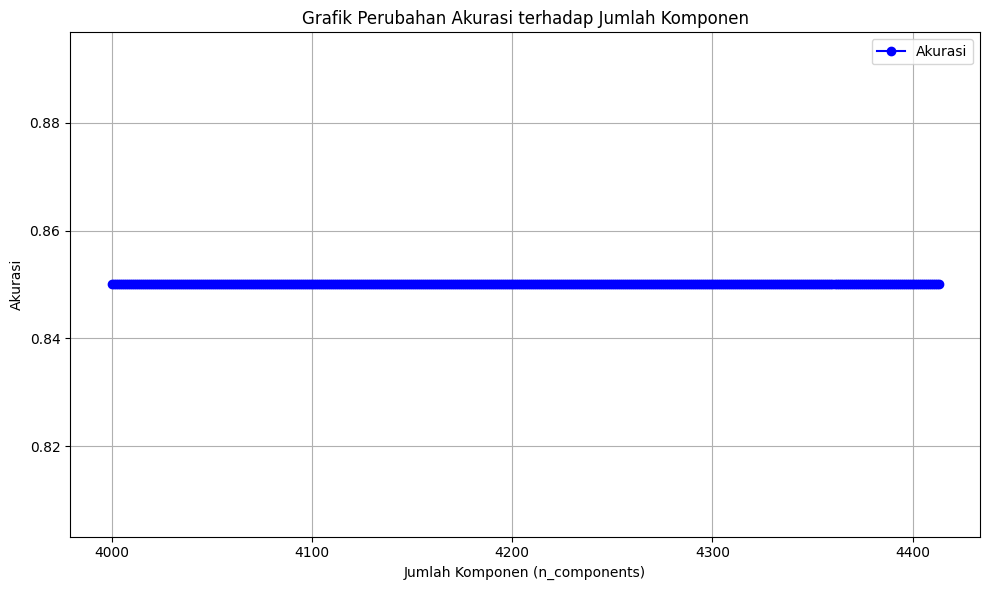

In [ ]:
best_accuracy = max(accuracy_list)
best_index = accuracy_list.index(best_accuracy)
best_num_components = num_components_list[best_index]

# Membuat grafik garis untuk akurasi vs jumlah komponen
plt.figure(figsize=(10, 6))
plt.plot(num_components_list, accuracy_list, marker='o', color='b', label='Akurasi')
plt.title("Grafik Perubahan Akurasi terhadap Jumlah Komponen")
plt.xlabel("Jumlah Komponen (n_components)")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend(loc='best')

#Menambahkan anotasi untuk best accuracy
#plt.annotate(
    #f'Best Accuracy: {best_accuracy:.2f}\nat {best_num_components} components',
    #xy=(best_num_components, best_accuracy),  # Koordinat posisi (x, y)
    #xytext=(best_num_components + 5, best_accuracy - 0.005),  # Posisi teks (di sebelah kanan atas titik)
    #arrowprops=dict(facecolor='black', arrowstyle='->'),  # Menambahkan panah
    #fontsize=10,
    #color='black'
#)
#plt.xticks(ticks=range(min(num_components_list), max(num_components_list) + 1, 10))

plt.tight_layout()

# Simpan grafik sebagai file jika diperlukan
plt.savefig("grafik4413.png")

# Tampilkan grafik
plt.show()

### Menampilkan plot dengan 4413 komponen

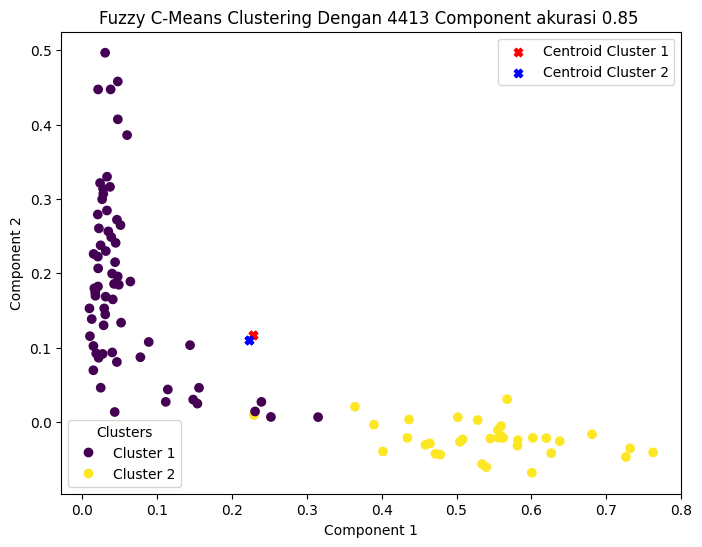

In [ ]:
# Menampilkan hasil scatter plot untuk komponen terbaik
best_result = max(results, key=lambda x: x["accuracy"])
best_labels = best_result["labels"]
best_centroids = best_result["centroids"]
best_num_components = best_result["num_components"]
best_accuracy = best_result["accuracy"]

# Mengurangi dimensi untuk komponen terbaik
svd_best = TruncatedSVD(n_components=best_num_components)
tfidf_best_reduced = svd_best.fit_transform(tfidf_matrix)

# Scatter plot hasil clustering
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tfidf_best_reduced[:, 0], tfidf_best_reduced[:, 1], c=best_labels, cmap='viridis', marker='o')

# Menambahkan centroid ke plot dengan sedikit pergeseran
shift_delta = 0.003  # Variabel untuk menggeser centroid agar tidak tumpang tindih

# Menambahkan centroid ke plot dengan pergeseran sedikit pada posisi centroid
for i in range(best_centroids.shape[0]):
    # Menentukan warna berdasarkan cluster
    color = 'red' if i == 0 else 'blue'  # Misalnya centroid cluster 1 merah, cluster 2 biru

    # Menggeser posisi centroid agar tidak tumpang tindih
    shift_x = best_centroids[i, 0] + (shift_delta if i == 0 else -shift_delta)
    shift_y = best_centroids[i, 1] + (shift_delta if i == 0 else -shift_delta)

    # Plot centroid yang telah digeser
    plt.scatter(shift_x, shift_y, c=color, marker='X')

# Menambahkan legenda untuk warna scatter (Cluster)
handles, _ = scatter.legend_elements(prop="colors")  # Ambil elemen warna dari scatter
legend_labels = [f'Cluster {i + 1}' for i in range(len(np.unique(best_labels)))]
cluster_legend = plt.legend(handles, legend_labels, title="Clusters", loc='lower left')

# Menambahkan legenda untuk centroids
plt.scatter(best_centroids[0, 0] + shift_delta, best_centroids[0, 1] + shift_delta, c='red', marker='X', label='Centroid Cluster 1')
plt.scatter(best_centroids[1, 0] - shift_delta, best_centroids[1, 1] - shift_delta, c='blue', marker='X', label='Centroid Cluster 2')

plt.gca().add_artist(cluster_legend)  # Tambahkan kembali legenda cluster agar tidak tertimpa

plt.title(f'Fuzzy C-Means Clustering Dengan 4413 Component akurasi {best_accuracy} ')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

# Menampilkan legenda
plt.legend(loc='best')

# Menyimpan gambar plot sebagai file PNG
plt.savefig('plot4413.png', dpi=300, bbox_inches='tight')
plt.show()

### Distribusi Kategori Dalam cluster

In [ ]:
df['cluster'] = best_labels
# Distribusi kategori dalam Cluster 1
cluster_1_dist = df[df['cluster'] == 0]['kategori'].value_counts().reset_index()
cluster_1_dist.columns = ['Kategori', 'Jumlah']

# Distribusi kategori dalam Cluster 2
cluster_2_dist = df[df['cluster'] == 1]['kategori'].value_counts().reset_index()
cluster_2_dist.columns = ['Kategori', 'Jumlah']
print("Distribusi Kategori dalam Cluster 1:")
print(cluster_1_dist)

print("\nDistribusi Kategori dalam Cluster 2:")
print(cluster_2_dist)

# Simpan ke CSV
#cluster_1_dist.to_csv('dis85-cluster1.csv', index=False)
#cluster_2_dist.to_csv('dis85-cluster2.csv', index=False)


Distribusi Kategori dalam Cluster 1:
   Kategori  Jumlah
0         0      50
1         1      15

Distribusi Kategori dalam Cluster 2:
   Kategori  Jumlah
0         1      35


## Pengurangan komponen 1 per satu ( mencari akurasi terbaik dari 300 komponen hingga 2 komponen)

In [ ]:
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score
from skfuzzy.cluster import cmeans

results = []
num_components_list = []
accuracy_list = []

for num_components in range(100,1, -1):
    # Mengurangi dimensi menggunakan SVD
    svd = TruncatedSVD(n_components=num_components, random_state=42)
    tfidf_reduced = svd.fit_transform(tfidf_matrix)

    # Transpose data agar sesuai dengan input skfuzzy (cmeans mengharapkan data dalam bentuk [fitur, sampel])
    data = tfidf_reduced.T

    # Fuzzy C-Means clustering menggunakan skfuzzy
    cntr, u, u0, d, jm, p, fpc = cmeans(
        data,                     # Data input
        c=2,                      # Jumlah cluster
        m=2,                      # Parameter fuzziness
        error=0.005,              # Toleransi error
        maxiter=200,              # Iterasi maksimum
        seed=42                   # Seed untuk random state
    )

    # Predict labels berdasarkan derajat keanggotaan maksimum
    labels = np.argmax(u, axis=0)

    # Evaluasi menggunakan akurasi
    accuracy = accuracy_score(true_labels, labels)
    results.append({
        "num_components": num_components,
        "accuracy": accuracy,
        "labels": labels,
        "centroids": cntr  # Menyimpan centroid dari FCM
    })

    num_components_list.append(num_components)
    accuracy_list.append(accuracy)


    print(f"Komponen: {num_components}, Accuracy: {accuracy}")


Komponen: 100, Accuracy: 0.85
Komponen: 99, Accuracy: 0.85
Komponen: 98, Accuracy: 0.86
Komponen: 97, Accuracy: 0.85
Komponen: 96, Accuracy: 0.86
Komponen: 95, Accuracy: 0.86
Komponen: 94, Accuracy: 0.86
Komponen: 93, Accuracy: 0.86
Komponen: 92, Accuracy: 0.87
Komponen: 91, Accuracy: 0.87
Komponen: 90, Accuracy: 0.87
Komponen: 89, Accuracy: 0.86
Komponen: 88, Accuracy: 0.85
Komponen: 87, Accuracy: 0.85
Komponen: 86, Accuracy: 0.85
Komponen: 85, Accuracy: 0.85
Komponen: 84, Accuracy: 0.84
Komponen: 83, Accuracy: 0.82
Komponen: 82, Accuracy: 0.78
Komponen: 81, Accuracy: 0.81
Komponen: 80, Accuracy: 0.82
Komponen: 79, Accuracy: 0.82
Komponen: 78, Accuracy: 0.84
Komponen: 77, Accuracy: 0.84
Komponen: 76, Accuracy: 0.85
Komponen: 75, Accuracy: 0.86
Komponen: 74, Accuracy: 0.85
Komponen: 73, Accuracy: 0.86
Komponen: 72, Accuracy: 0.86
Komponen: 71, Accuracy: 0.86
Komponen: 70, Accuracy: 0.86
Komponen: 69, Accuracy: 0.85
Komponen: 68, Accuracy: 0.85
Komponen: 67, Accuracy: 0.85
Komponen: 66,

## Menampilkan Grafik

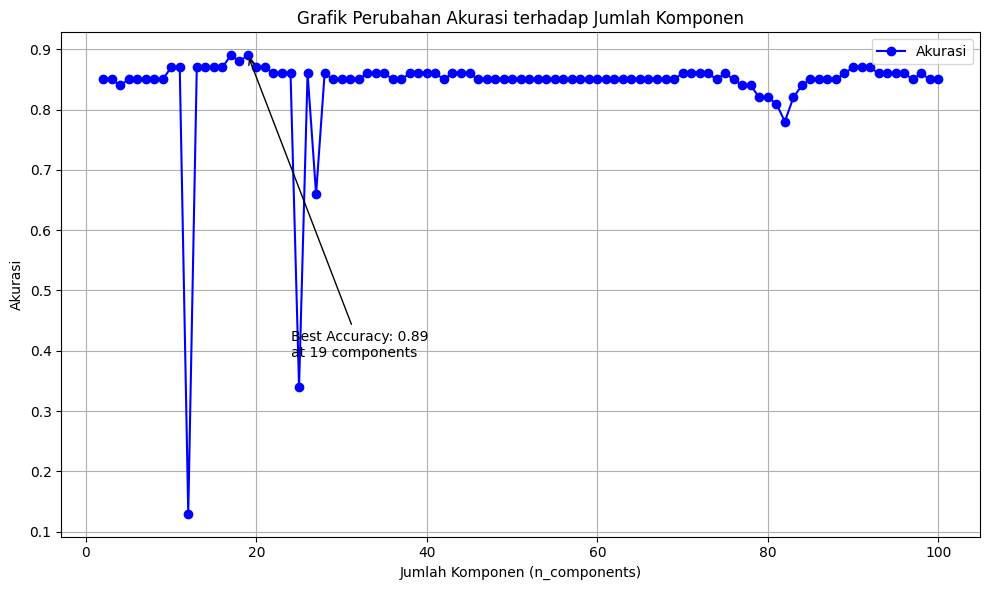

In [ ]:
best_accuracy = max(accuracy_list)
best_index = accuracy_list.index(best_accuracy)
best_num_components = num_components_list[best_index]

# Membuat grafik garis untuk akurasi vs jumlah komponen
plt.figure(figsize=(10, 6))
plt.plot(num_components_list, accuracy_list, marker='o', color='b', label='Akurasi')
plt.title("Grafik Perubahan Akurasi terhadap Jumlah Komponen")
plt.xlabel("Jumlah Komponen (n_components)")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend(loc='best')

#Menambahkan anotasi untuk best accuracy
plt.annotate(
    f'Best Accuracy: {best_accuracy:.2f}\nat {best_num_components} components',
    xy=(best_num_components, best_accuracy),  # Koordinat posisi (x, y)
    xytext=(best_num_components + 5, best_accuracy - 0.5),  # Posisi teks (di sebelah kanan atas titik)
    arrowprops=dict(facecolor='black', arrowstyle='->'),  # Menambahkan panah
    fontsize=10,
    color='black'
)

# Mengatur ticks pada sumbu-x dimulai dari 5, 10, 15, dst.
#plt.xticks(ticks=range(min(num_components_list), max(num_components_list) + 1,5 ))

plt.tight_layout()

# Simpan grafik sebagai file jika diperlukan
plt.savefig("grafik300-2.png")

# Tampilkan grafik
plt.show()

### Menampilkan plot setelah svd, berdasarkan pencarian komponen dengan akurasi terbaik

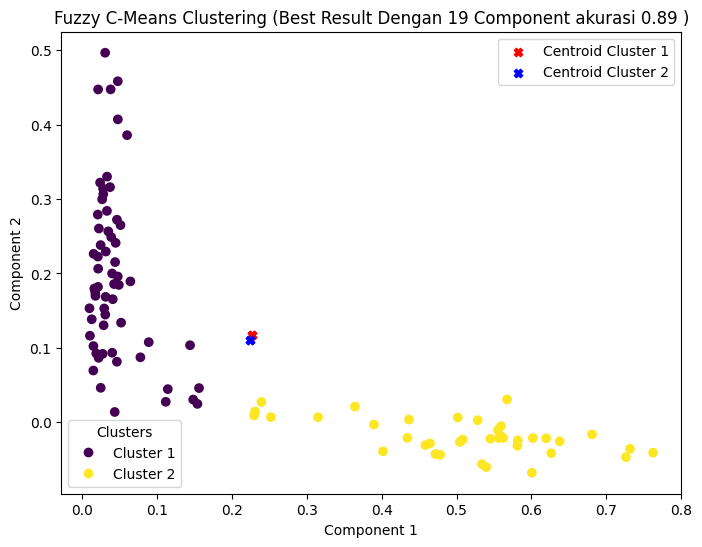

In [ ]:
# Menampilkan hasil scatter plot untuk komponen terbaik
best_result = max(results, key=lambda x: x["accuracy"])
best_labels = best_result["labels"]
best_centroids = best_result["centroids"]
best_num_components = best_result["num_components"]
best_accuracy = best_result["accuracy"]

# Mengurangi dimensi untuk komponen terbaik
svd_best = TruncatedSVD(n_components=best_num_components)
tfidf_best_reduced = svd_best.fit_transform(tfidf_matrix)

# Scatter plot hasil clustering
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tfidf_best_reduced[:, 0], tfidf_best_reduced[:, 1], c=best_labels, cmap='viridis', marker='o')

# Menambahkan centroid ke plot dengan sedikit pergeseran
shift_delta = 0.003  # Variabel untuk menggeser centroid agar tidak tumpang tindih

# Menambahkan centroid ke plot dengan pergeseran sedikit pada posisi centroid
for i in range(best_centroids.shape[0]):
    # Menentukan warna berdasarkan cluster
    color = 'red' if i == 0 else 'blue'  # Misalnya centroid cluster 1 merah, cluster 2 biru

    # Menggeser posisi centroid agar tidak tumpang tindih
    shift_x = best_centroids[i, 0] + (shift_delta if i == 0 else -shift_delta)
    shift_y = best_centroids[i, 1] + (shift_delta if i == 0 else -shift_delta)

    # Plot centroid yang telah digeser
    plt.scatter(shift_x, shift_y, c=color, marker='X')

# Menambahkan legenda untuk warna scatter (Cluster)
handles, _ = scatter.legend_elements(prop="colors")  # Ambil elemen warna dari scatter
legend_labels = [f'Cluster {i + 1}' for i in range(len(np.unique(best_labels)))]
cluster_legend = plt.legend(handles, legend_labels, title="Clusters", loc='lower left')

# Menambahkan legenda untuk centroids
plt.scatter(best_centroids[0, 0] + shift_delta, best_centroids[0, 1] + shift_delta, c='red', marker='X', label='Centroid Cluster 1')
plt.scatter(best_centroids[1, 0] - shift_delta, best_centroids[1, 1] - shift_delta, c='blue', marker='X', label='Centroid Cluster 2')

plt.gca().add_artist(cluster_legend)  # Tambahkan kembali legenda cluster agar tidak tertimpa

plt.title(f'Fuzzy C-Means Clustering (Best Result Dengan {best_num_components} Component akurasi {best_accuracy} )')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

# Menampilkan legenda
plt.legend(loc='best')

plt.savefig('plot19.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
svd_best = TruncatedSVD(n_components=best_num_components, random_state=42)
tfidf_best_reduced = svd_best.fit_transform(tfidf_matrix)

print(f"Jumlah Komponen Terbaik: {best_num_components}")
print(f"Akurasi: {best_accuracy}")
print(f"Dimensi Data Setelah Reduksi SVD (Komponen Terbaik): {tfidf_best_reduced.shape}")

# Menampilkan isi centroid terbaik
print("Isi Centroid Terbaik:")
print(best_centroids)



Jumlah Komponen Terbaik: 19
Akurasi: 0.89
Dimensi Data Setelah Reduksi SVD (Komponen Terbaik): (100, 19)
Isi Centroid Terbaik:
[[ 0.22451219  0.11403016  0.00741638  0.01840847  0.00925721 -0.01087861
   0.0239571   0.01206712 -0.00901117 -0.0006618   0.00523296  0.0107058
   0.00023511 -0.00655039 -0.00473033  0.00210321  0.0066023   0.00052728
   0.00790842]
 [ 0.22736449  0.11291603  0.00733638  0.0181037   0.00923354 -0.01068436
   0.0237967   0.01184351 -0.00906301 -0.00098216  0.0052042   0.01069081
   0.00036109 -0.00643043 -0.00465767  0.00202415  0.00643368  0.00054862
   0.00788758]]


### Distribusi Kategori Dalam cluster

In [ ]:
df['cluster'] = best_labels
# Distribusi kategori dalam Cluster 1
cluster_1_dist = df[df['cluster'] == 0]['kategori'].value_counts().reset_index()
cluster_1_dist.columns = ['Kategori', 'Jumlah']

# Distribusi kategori dalam Cluster 2
cluster_2_dist = df[df['cluster'] == 1]['kategori'].value_counts().reset_index()
cluster_2_dist.columns = ['Kategori', 'Jumlah']
print("Distribusi Kategori dalam Cluster 1:")
print(cluster_1_dist)

print("\nDistribusi Kategori dalam Cluster 2:")
print(cluster_2_dist)

# Simpan ke CSV
cluster_1_dist.to_csv('dis89-cluster1.csv', index=False)
cluster_2_dist.to_csv('dis89-cluster2.csv', index=False)


Distribusi Kategori dalam Cluster 1:
   Kategori  Jumlah
0         0      50
1         1      11

Distribusi Kategori dalam Cluster 2:
   Kategori  Jumlah
0         1      39
